# 🎯 AI Career Pilot — Full Data Analysis Notebook

> **Dataset:** Kaggle Career Dataset (`kaggle_career_dataset.csv`)  
> **Goal:** End-to-end analysis — EDA → Cleaning → Outlier Removal → Correlations → Feature Engineering → Model Training & Comparison

---

### 📋 Notebook Sections
1. **Setup & Data Loading**
2. **Exploratory Data Analysis (EDA)**
3. **Data Cleaning — Duplicates & Missing Values**
4. **Outlier Detection & Removal**
5. **Correlation Analysis**
6. **Feature Distribution Visualizations**
7. **Feature Engineering**
8. **Model Training — Random Forest, SVM, KNN**
9. **Model Comparison & Results**

---

## 📦 Section 1 — Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.sparse import hstack
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


In [3]:
# ── Load the dataset ──────────────────────────────────────────────────────────
RAW_CSV   = 'kaggle_career_dataset.csv'
CLEAN_CSV = 'kaggle_career_dataset_cleaned.csv'

df_raw = pd.read_csv(RAW_CSV)

print(f'📊 Raw Dataset Shape : {df_raw.shape}')
print(f'📋 Columns           : {list(df_raw.columns)}')
df_raw.head()

📊 Raw Dataset Shape : (515000, 8)
📋 Columns           : ['User_ID', 'Age', 'Academic_Percentage', 'Technical_Skills', 'Soft_Skills', 'Interest_Areas', 'Extracurriculars', 'Career_Path']


,User_ID,Age,Academic_Percentage,Technical_Skills,Soft_Skills,Interest_Areas,Extracurriculars,Career_Path
0,1,19,87.713091,"SEO,Graphic Design,Athletic Training,Coaching","Critical Thinking,Teamwork,Adaptability,Time M...",Art,Gardening Club,Graphic Designer
1,2,20,60.014482,"Cybersecurity,Video Editing,Sketching","Problem Solving,Ethics,Discipline",Environment,Sports,Professional Athlete
2,3,21,85.899951,"React,Military Strategy,SEO,Structural Analysis","Leadership,Resilience",Finance,Gardening Club,Army Officer
3,4,20,91.196282,"Chemistry,Kinesiology,SQL,Sports Science","Leadership,Problem Solving,Resilience,Time Man...",Sports/Fitness,Sports,Professional Athlete
4,5,19,84.025007,"Policy Analysis,Content Writing,Kinesiology,Cy...","Public Speaking,Teamwork,Critical Thinking,Com...",Sustainability,ROTC/Cadets,Content Writer


In [4]:
# Also load the small local dataset for reference
df_small = pd.read_csv('career_data.csv')
print('\n🗂️ Small Local Dataset:')
print(df_small.to_string(index=False))


🗂️ Small Local Dataset:
             career_title    industry  aptitude_score  demand_growth  required_experience_years
        Software Engineer  Technology              95            5.2                          0
        Software Engineer  Technology              95            5.2                          0
           Data Scientist  Technology              90            7.1                          2
Machine Learning Engineer  Technology             110            6.5                          1
         Graphic Designer      Design              75            2.1                          0
           Digital Artist      Design              80            3.4                          0
                    Nurse  Healthcare              85            4.8                          3
                    Nurse  Healthcare              85            4.8                          3
                  Surgeon  Healthcare             150            2.5                         10
               

## 🔍 Section 2 — Exploratory Data Analysis (EDA)

In [5]:
# ── Basic Info ───────────────────────────────────────────────────────────────
print('=' * 60)
print('DATASET INFO')
print('=' * 60)
df_raw.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515000 entries, 0 to 514999
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   User_ID              515000 non-null  int64  
 1   Age                  515000 non-null  int64  
 2   Academic_Percentage  509876 non-null  float64
 3   Technical_Skills     515000 non-null  object 
 4   Soft_Skills          515000 non-null  object 
 5   Interest_Areas       515000 non-null  object 
 6   Extracurriculars     515000 non-null  object 
 7   Career_Path          515000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 31.4+ MB


In [6]:
# ── Descriptive Statistics ────────────────────────────────────────────────────
print('=' * 60)
print('DESCRIPTIVE STATISTICS — Numerical Features')
print('=' * 60)
df_raw.describe().T.style.background_gradient(cmap='Blues')

DESCRIPTIVE STATISTICS — Numerical Features


,count,mean,std,min,25%,50%,75%,max
User_ID,515000.000000,250039.893435,144328.840287,1.000000,125085.750000,250082.500000,375056.250000,500000.000000
Age,515000.000000,20.997893,2.002926,18.000000,19.000000,21.000000,23.000000,24.000000
Academic_Percentage,509876.000000,81.372561,23.075380,60.000026,70.049367,80.136101,90.187474,499.636780


                     Missing Count  Missing %
Academic_Percentage           5124       0.99


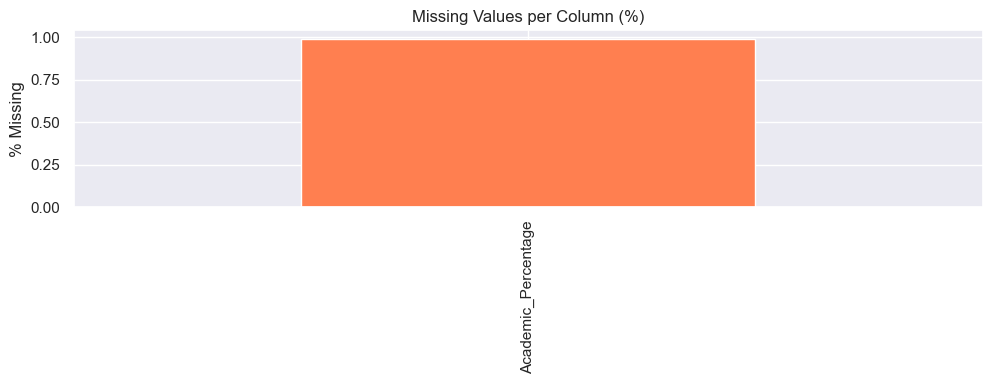

In [7]:
# ── Missing Values ────────────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print('✅ No missing values found in the dataset!')
else:
    print(missing_df)
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Missing %'].plot(kind='bar', color='coral', ax=ax)
    ax.set_title('Missing Values per Column (%)')
    ax.set_ylabel('% Missing')
    plt.tight_layout()
    plt.show()

🎯 Total unique careers: 33
Career_Path
Professional Athlete     60267
Army Officer             39936
Content Writer           37360
Lawyer                   34561
Nurse                    27564
Sports Coach             22765
Graphic Designer         22336
HR Manager               19901
Doctor                   17860
Agriculturist            16406
Landscape Architect      16121
Accountant               16098
Financial Analyst        15804
Intelligence Analyst     14311
Product Manager          13811
Cybersecurity Analyst    13709
Air Force Pilot          12111
Pharmacist               11581
Botanist                 11404
Cloud Architect          11128
Name: count, dtype: int64


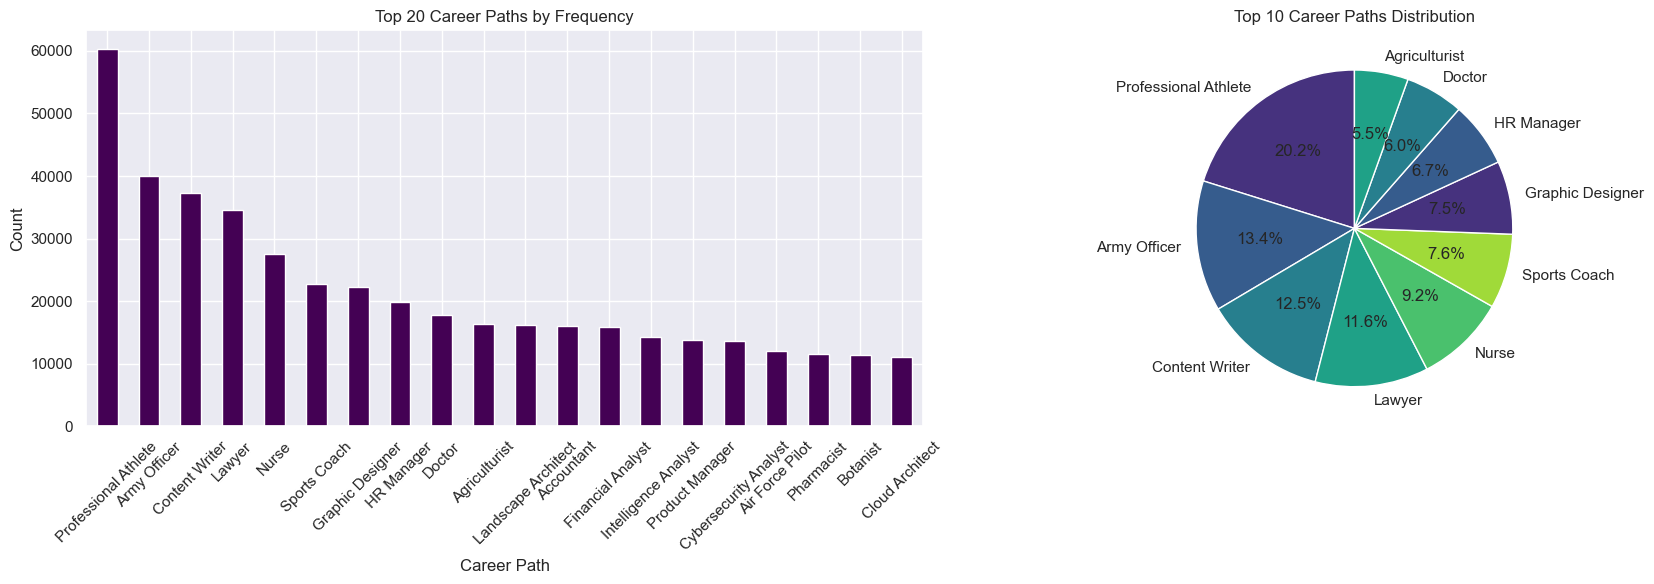

In [8]:
# ── Target Class Distribution ─────────────────────────────────────────────────
career_counts = df_raw['Career_Path'].value_counts()
print(f'🎯 Total unique careers: {career_counts.nunique()}')
print(career_counts.head(20))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 20 careers bar chart
career_counts.head(20).plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Top 20 Career Paths by Frequency')
axes[0].set_xlabel('Career Path')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart top 10
career_counts.head(10).plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Top 10 Career Paths Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

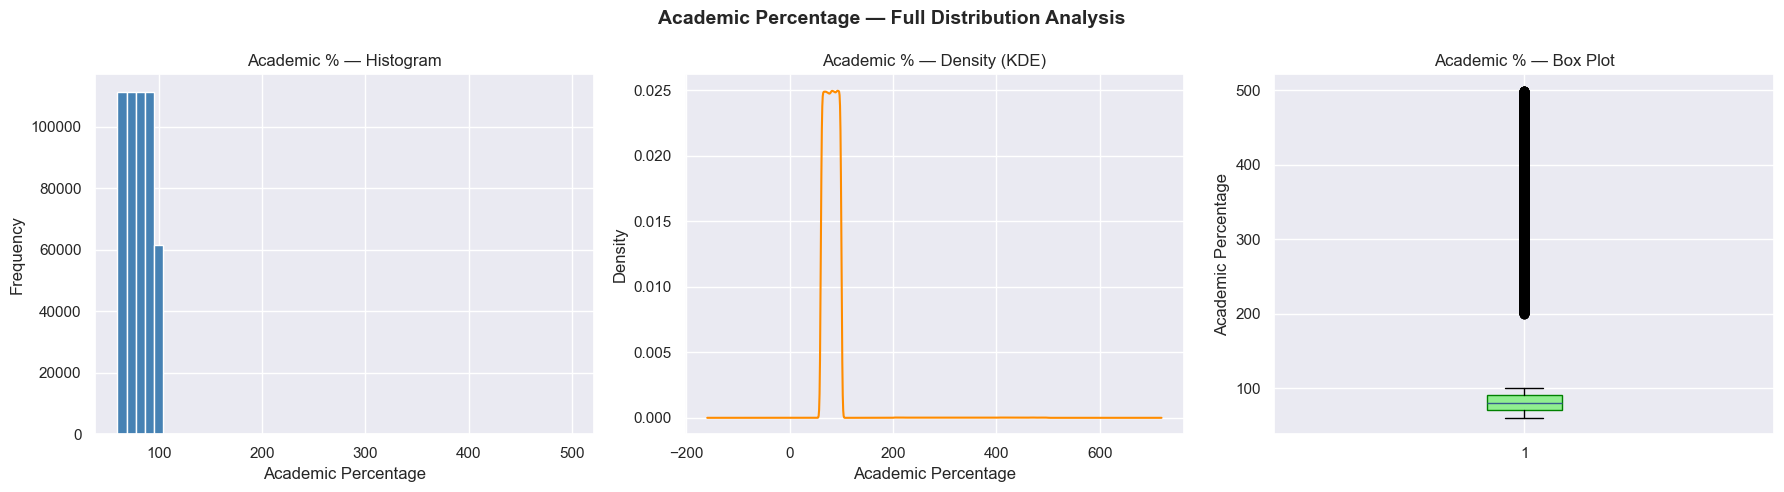


Mean   : 81.37
Median : 80.14
Std Dev: 23.08
Skew   : 10.2281
Kurt   : 146.0067


In [9]:
# ── Academic Percentage Distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df_raw['Academic_Percentage'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Academic % — Histogram')
axes[0].set_xlabel('Academic Percentage')
axes[0].set_ylabel('Frequency')

# KDE Plot
df_raw['Academic_Percentage'].dropna().plot(kind='density', ax=axes[1], color='darkorange')
axes[1].set_title('Academic % — Density (KDE)')
axes[1].set_xlabel('Academic Percentage')

# Box Plot
axes[2].boxplot(df_raw['Academic_Percentage'].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightgreen', color='green'))
axes[2].set_title('Academic % — Box Plot')
axes[2].set_ylabel('Academic Percentage')

plt.suptitle('Academic Percentage — Full Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nMean   : {df_raw['Academic_Percentage'].mean():.2f}")
print(f"Median : {df_raw['Academic_Percentage'].median():.2f}")
print(f"Std Dev: {df_raw['Academic_Percentage'].std():.2f}")
print(f"Skew   : {df_raw['Academic_Percentage'].skew():.4f}")
print(f"Kurt   : {df_raw['Academic_Percentage'].kurt():.4f}")

ValueError: x and y must be the same size

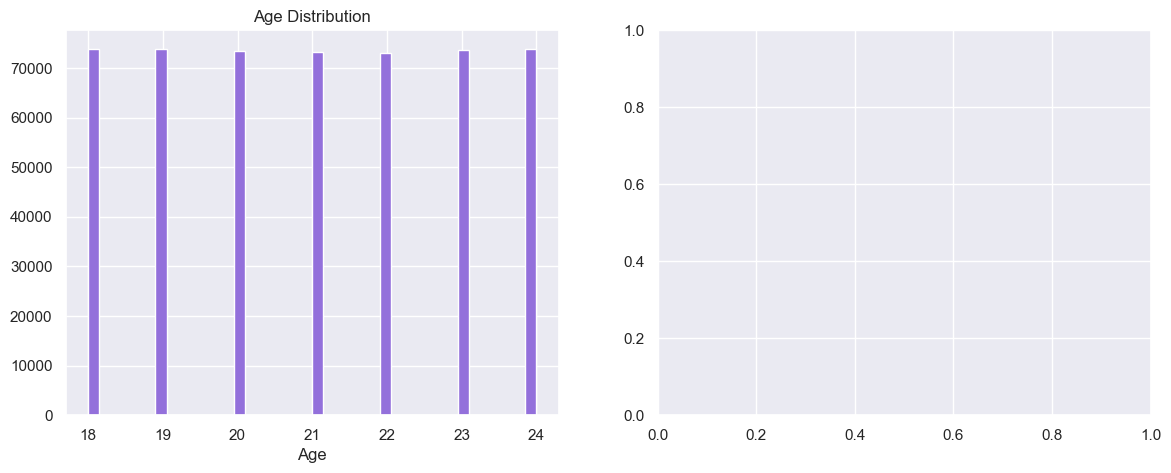

In [10]:
# ── Age Distribution ──────────────────────────────────────────────────────────
if 'Age' in df_raw.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    df_raw['Age'].dropna().hist(bins=40, ax=axes[0], color='mediumpurple', edgecolor='white')
    axes[0].set_title('Age Distribution')
    axes[0].set_xlabel('Age')

    # Age vs Academic %
    axes[1].scatter(df_raw['Age'].dropna(), df_raw['Academic_Percentage'].dropna(),
                   alpha=0.3, s=5, c='teal')
    axes[1].set_title('Age vs Academic Percentage')
    axes[1].set_xlabel('Age')
    axes[1].set_ylabel('Academic %')

    plt.tight_layout()
    plt.show()

## 🧹 Section 3 — Data Cleaning (Duplicates & Missing Values)

In [11]:
df = df_raw.copy()

print('=' * 55)
print('BEFORE CLEANING')
print('=' * 55)
print(f'  Total rows         : {len(df):,}')
print(f'  Duplicate rows     : {df.duplicated().sum():,}')
print(f'  Missing values     : {df.isnull().sum().sum():,}')

# Step 1 – Remove duplicate rows
before_dedup = len(df)
df.drop_duplicates(inplace=True)
removed_dupes = before_dedup - len(df)
print(f'\n🗑️  Removed {removed_dupes:,} duplicate rows')

# Step 2 – Drop rows with missing values in critical columns
critical_cols = ['Academic_Percentage', 'Career_Path']
before_na = len(df)
df.dropna(subset=critical_cols, inplace=True)
removed_na = before_na - len(df)
print(f'🗑️  Removed {removed_na:,} rows with missing critical values')

# Step 3 – Fill remaining NaN in text columns with 'Unknown'
text_cols = df.select_dtypes(include='object').columns
df[text_cols] = df[text_cols].fillna('Unknown')

print('\n' + '=' * 55)
print('AFTER CLEANING')
print('=' * 55)
print(f'  Total rows         : {len(df):,}')
print(f'  Duplicate rows     : {df.duplicated().sum():,}')
print(f'  Missing values     : {df.isnull().sum().sum():,}')
print(f'\n✅ Clean dataset ready! Retained {len(df)/before_dedup*100:.1f}% of original data.')

BEFORE CLEANING
  Total rows         : 515,000
  Duplicate rows     : 14,550
  Missing values     : 5,124

🗑️  Removed 14,550 duplicate rows
🗑️  Removed 5,121 rows with missing critical values

AFTER CLEANING
  Total rows         : 495,329
  Duplicate rows     : 0
  Missing values     : 0

✅ Clean dataset ready! Retained 96.2% of original data.


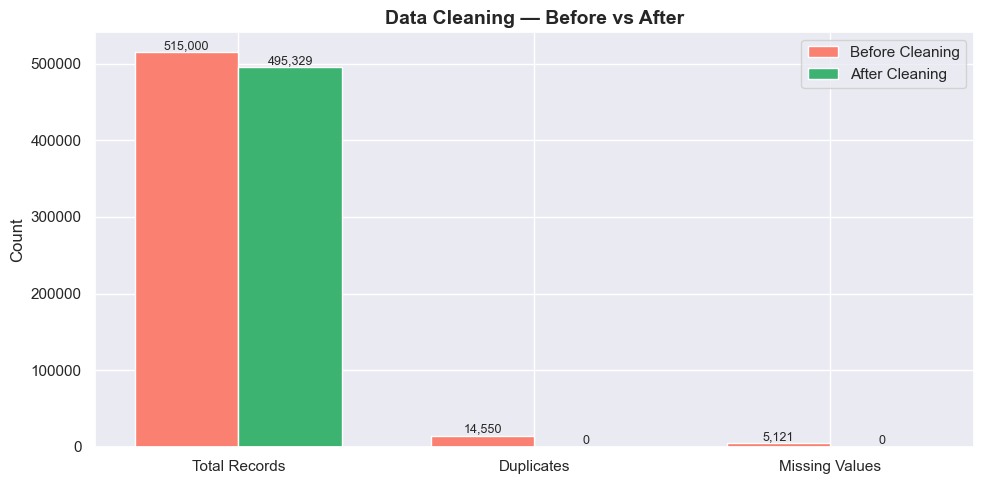

In [12]:
# Before/After cleaning comparison bar chart
labels = ['Total Records', 'Duplicates', 'Missing Values']
before = [before_dedup, removed_dupes, removed_na]
after  = [len(df), 0, 0]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, before, width, label='Before Cleaning', color='salmon')
bars2 = ax.bar(x + width/2, after,  width, label='After Cleaning',  color='mediumseagreen')

ax.set_title('Data Cleaning — Before vs After', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Count')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 📐 Section 4 — Outlier Detection & Removal

📊 Z-Score Outlier Analysis (threshold = 3σ):
   Outliers detected  : 2,575
   % of dataset       : 0.520%


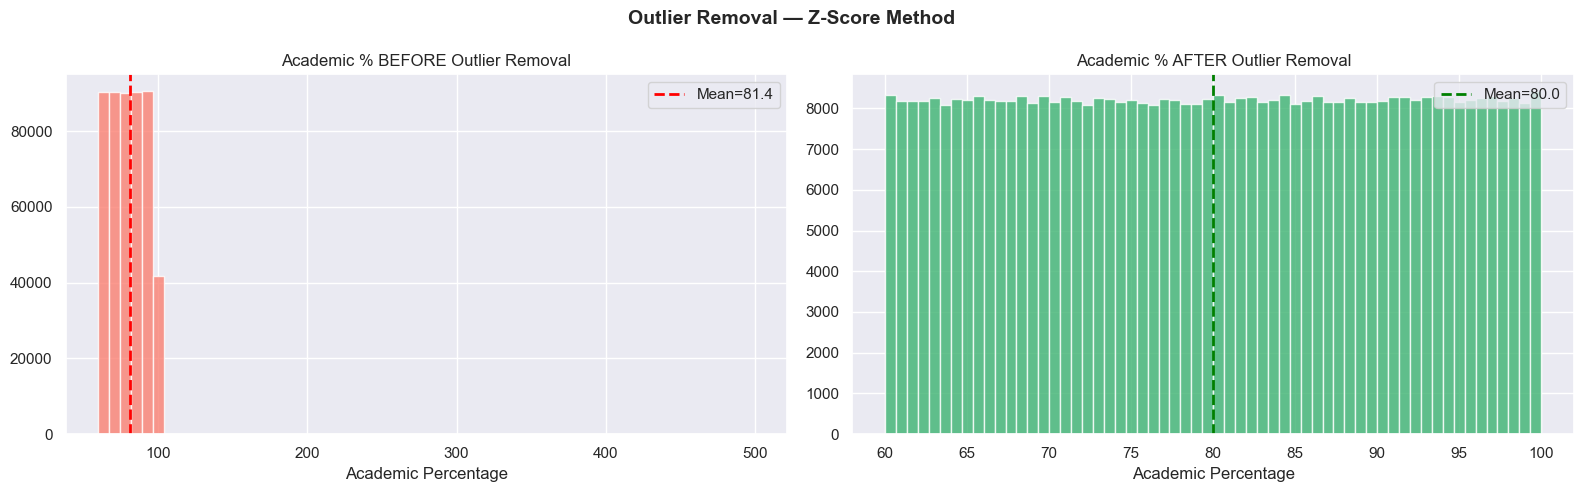


✅ Removed 2,575 outliers. Dataset: 492,754 rows


In [13]:
# ── Z-Score Method on Academic_Percentage ─────────────────────────────────────
z_scores = np.abs(stats.zscore(df['Academic_Percentage']))
outlier_mask = z_scores > 3

print(f'📊 Z-Score Outlier Analysis (threshold = 3σ):')
print(f'   Outliers detected  : {outlier_mask.sum():,}')
print(f'   % of dataset       : {outlier_mask.sum()/len(df)*100:.3f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before
axes[0].hist(df['Academic_Percentage'], bins=60, color='salmon', edgecolor='white', alpha=0.8)
axes[0].set_title('Academic % BEFORE Outlier Removal')
axes[0].set_xlabel('Academic Percentage')
mean_before = df['Academic_Percentage'].mean()
axes[0].axvline(mean_before, color='red', linewidth=2, linestyle='--', label=f'Mean={mean_before:.1f}')
axes[0].legend()

# Remove outliers
rows_before = len(df)
df = df[z_scores <= 3].copy()
rows_after = len(df)

# After
axes[1].hist(df['Academic_Percentage'], bins=60, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[1].set_title('Academic % AFTER Outlier Removal')
axes[1].set_xlabel('Academic Percentage')
mean_after = df['Academic_Percentage'].mean()
axes[1].axvline(mean_after, color='green', linewidth=2, linestyle='--', label=f'Mean={mean_after:.1f}')
axes[1].legend()

plt.suptitle('Outlier Removal — Z-Score Method', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n✅ Removed {rows_before - rows_after:,} outliers. Dataset: {rows_after:,} rows')

📐 IQR Method Summary:
   Q1 (25th percentile) : 70.00
   Q3 (75th percentile) : 90.04
   IQR                  : 20.04
   Lower bound          : 39.93
   Upper bound          : 120.10
   IQR Outliers found   : 0


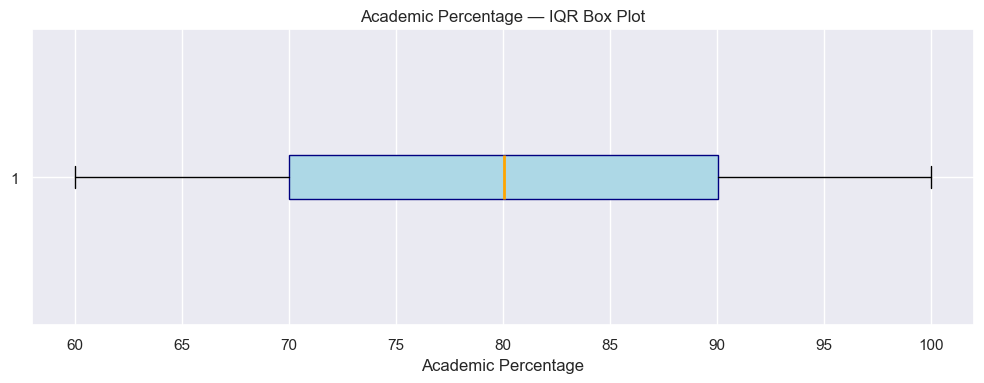

In [14]:
# ── IQR Method (for comparison / double-check) ────────────────────────────────
Q1 = df['Academic_Percentage'].quantile(0.25)
Q3 = df['Academic_Percentage'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df[(df['Academic_Percentage'] < lower_bound) | (df['Academic_Percentage'] > upper_bound)]

print(f'📐 IQR Method Summary:')
print(f'   Q1 (25th percentile) : {Q1:.2f}')
print(f'   Q3 (75th percentile) : {Q3:.2f}')
print(f'   IQR                  : {IQR:.2f}')
print(f'   Lower bound          : {lower_bound:.2f}')
print(f'   Upper bound          : {upper_bound:.2f}')
print(f'   IQR Outliers found   : {len(iqr_outliers):,}')

# Box plot with IQR bounds highlighted
fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(df['Academic_Percentage'], vert=False, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           flierprops=dict(marker='o', color='red', markersize=4),
           medianprops=dict(color='orange', linewidth=2))
ax.set_title('Academic Percentage — IQR Box Plot')
ax.set_xlabel('Academic Percentage')
plt.tight_layout()
plt.show()

## 🔗 Section 5 — Correlation Analysis

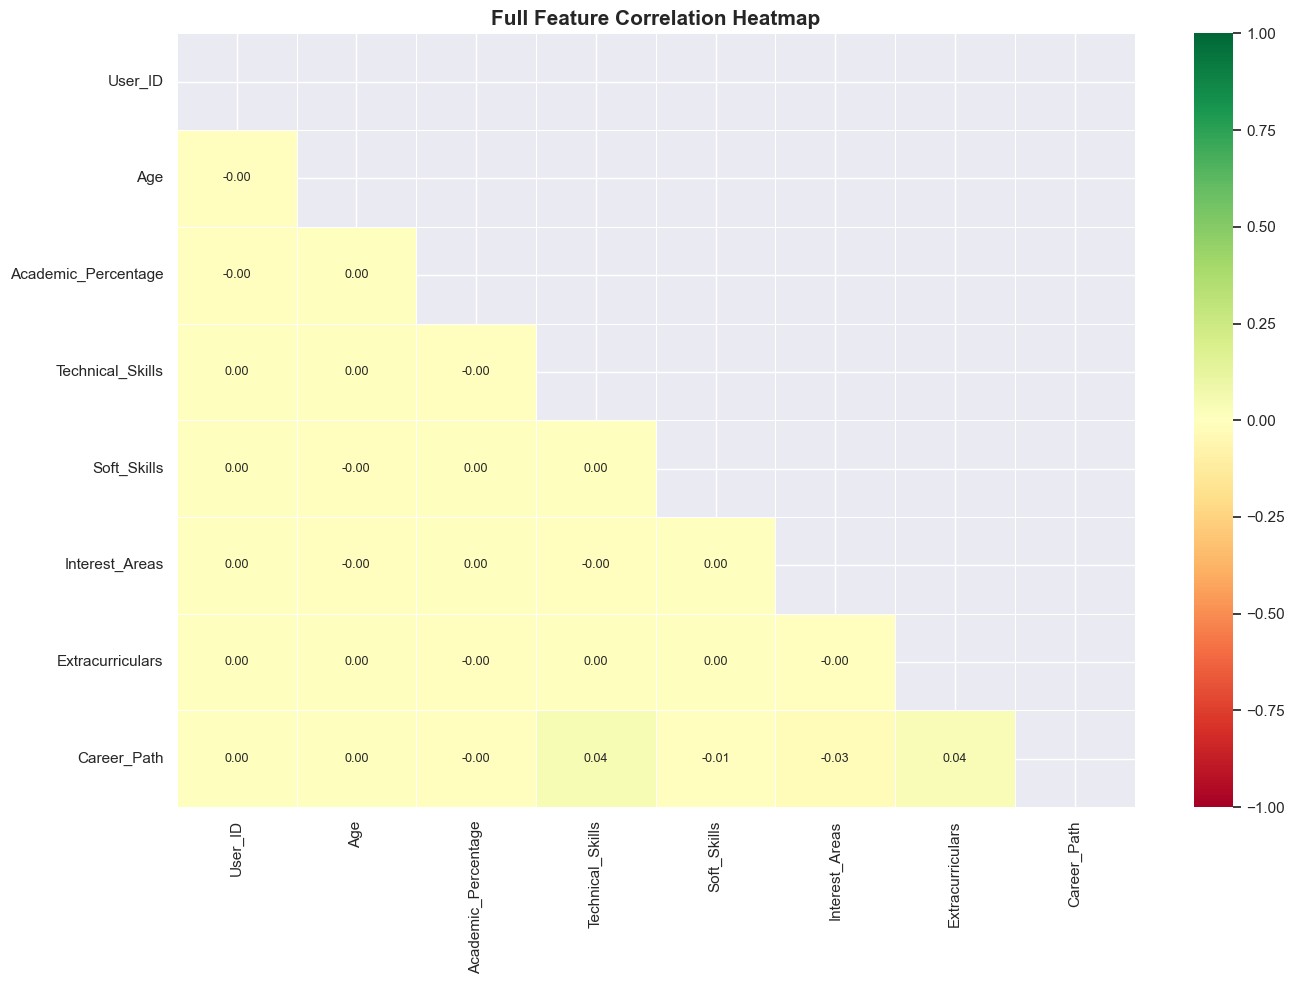

In [15]:
# ── Encode categorical columns for correlation ────────────────────────────────
df_encoded = df.copy()

label_encoders = {}
for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

# ── Full Correlation Heatmap ──────────────────────────────────────────────────
numeric_df = df_encoded.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # only lower triangle
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    annot_kws={'size': 9}, vmin=-1, vmax=1
)
plt.title('Full Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

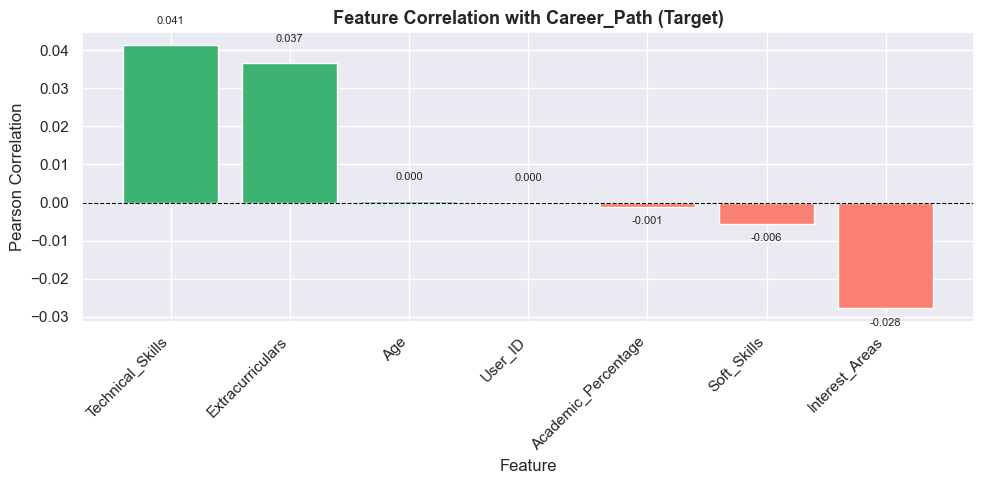

📊 Top correlated features with Career_Path:
Technical_Skills       0.041266
Extracurriculars       0.036614
Age                    0.000282
User_ID                0.000189
Academic_Percentage   -0.001187
Soft_Skills           -0.005501
Interest_Areas        -0.027823


In [16]:
# ── Correlation with Career_Path (target) ────────────────────────────────────
if 'Career_Path' in corr_matrix.columns:
    target_corr = corr_matrix['Career_Path'].drop('Career_Path').sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    colors = ['mediumseagreen' if v >= 0 else 'salmon' for v in target_corr.values]
    plt.bar(target_corr.index, target_corr.values, color=colors, edgecolor='white')
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    plt.title('Feature Correlation with Career_Path (Target)', fontsize=13, fontweight='bold')
    plt.xlabel('Feature')
    plt.ylabel('Pearson Correlation')
    plt.xticks(rotation=45, ha='right')
    for i, (col, val) in enumerate(zip(target_corr.index, target_corr.values)):
        plt.text(i, val + 0.005 * np.sign(val), f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()

    print('📊 Top correlated features with Career_Path:')
    print(target_corr.to_string())

## 📊 Section 6 — Feature Distribution Visualizations

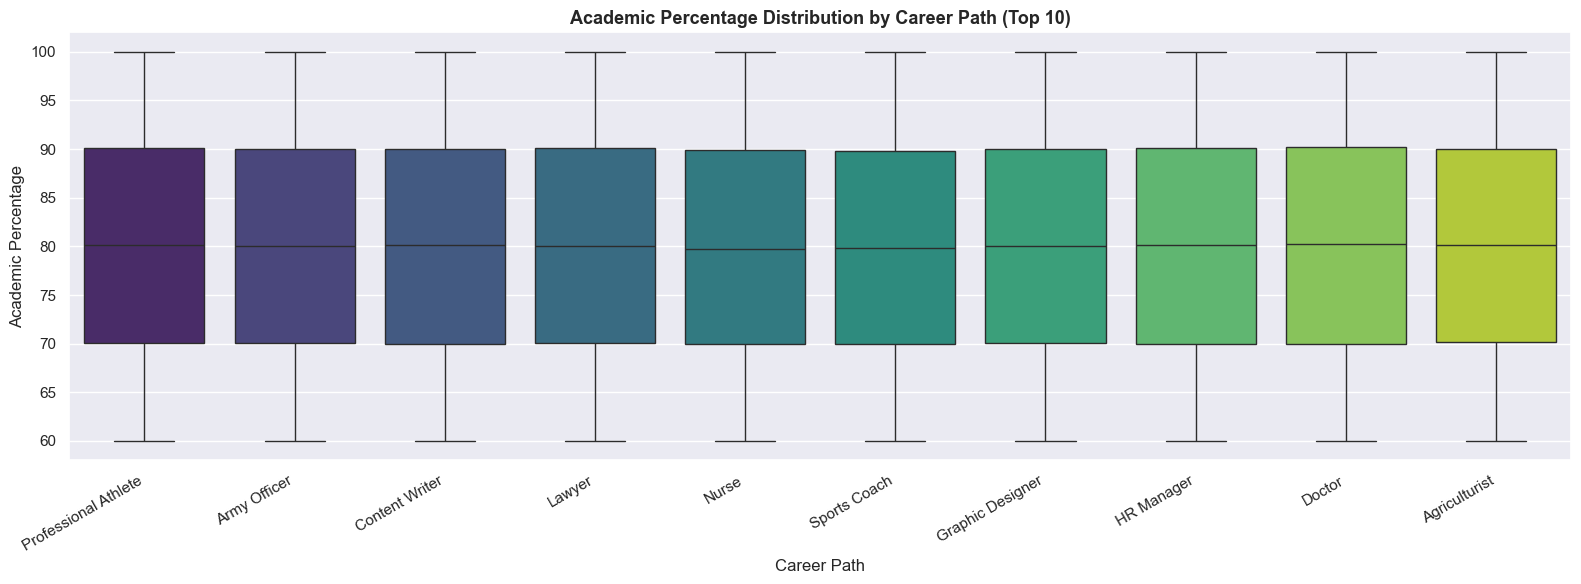

In [17]:
# ── Academic % by Career Path (top 10 careers) ───────────────────────────────
top_careers = df['Career_Path'].value_counts().head(10).index
df_top = df[df['Career_Path'].isin(top_careers)]

plt.figure(figsize=(16, 6))
sns.boxplot(
    data=df_top, x='Career_Path', y='Academic_Percentage',
    palette='viridis', order=top_careers
)
plt.title('Academic Percentage Distribution by Career Path (Top 10)', fontsize=13, fontweight='bold')
plt.xlabel('Career Path')
plt.ylabel('Academic Percentage')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

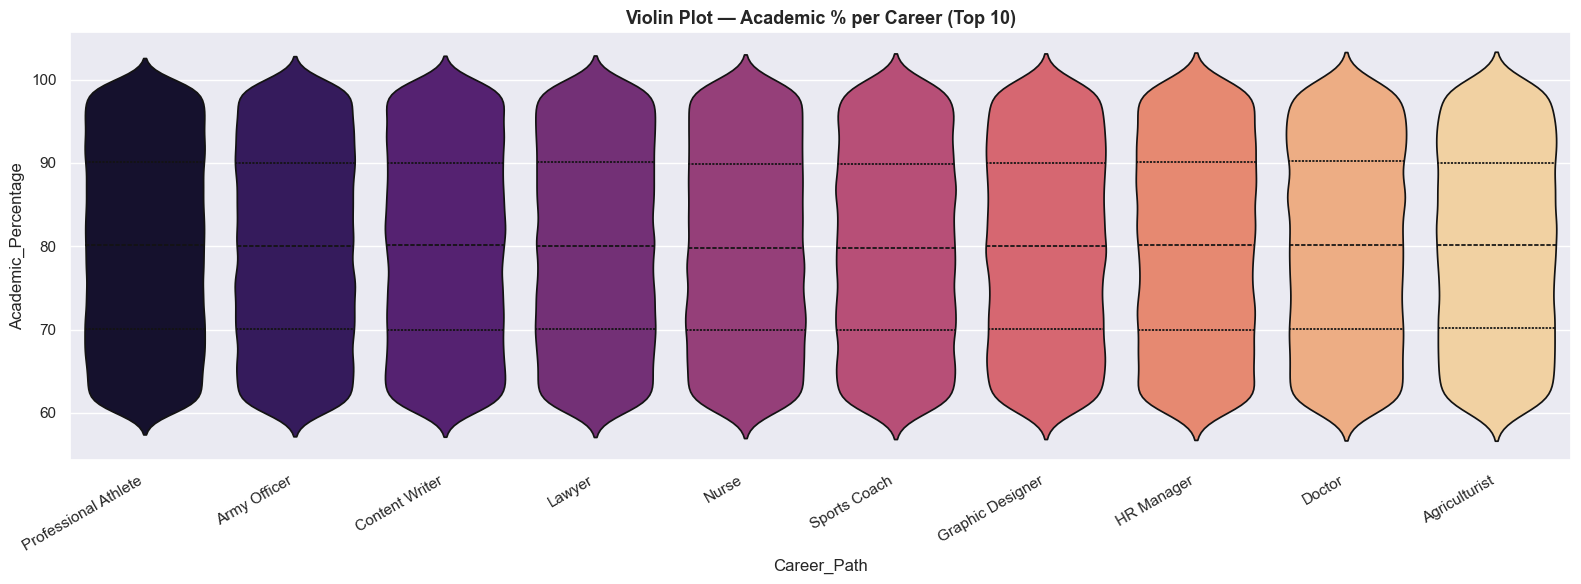

In [18]:
# ── Violin Plot — Academic % per Career ──────────────────────────────────────
plt.figure(figsize=(16, 6))
sns.violinplot(
    data=df_top, x='Career_Path', y='Academic_Percentage',
    palette='magma', order=top_careers, inner='quartile'
)
plt.title('Violin Plot — Academic % per Career (Top 10)', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

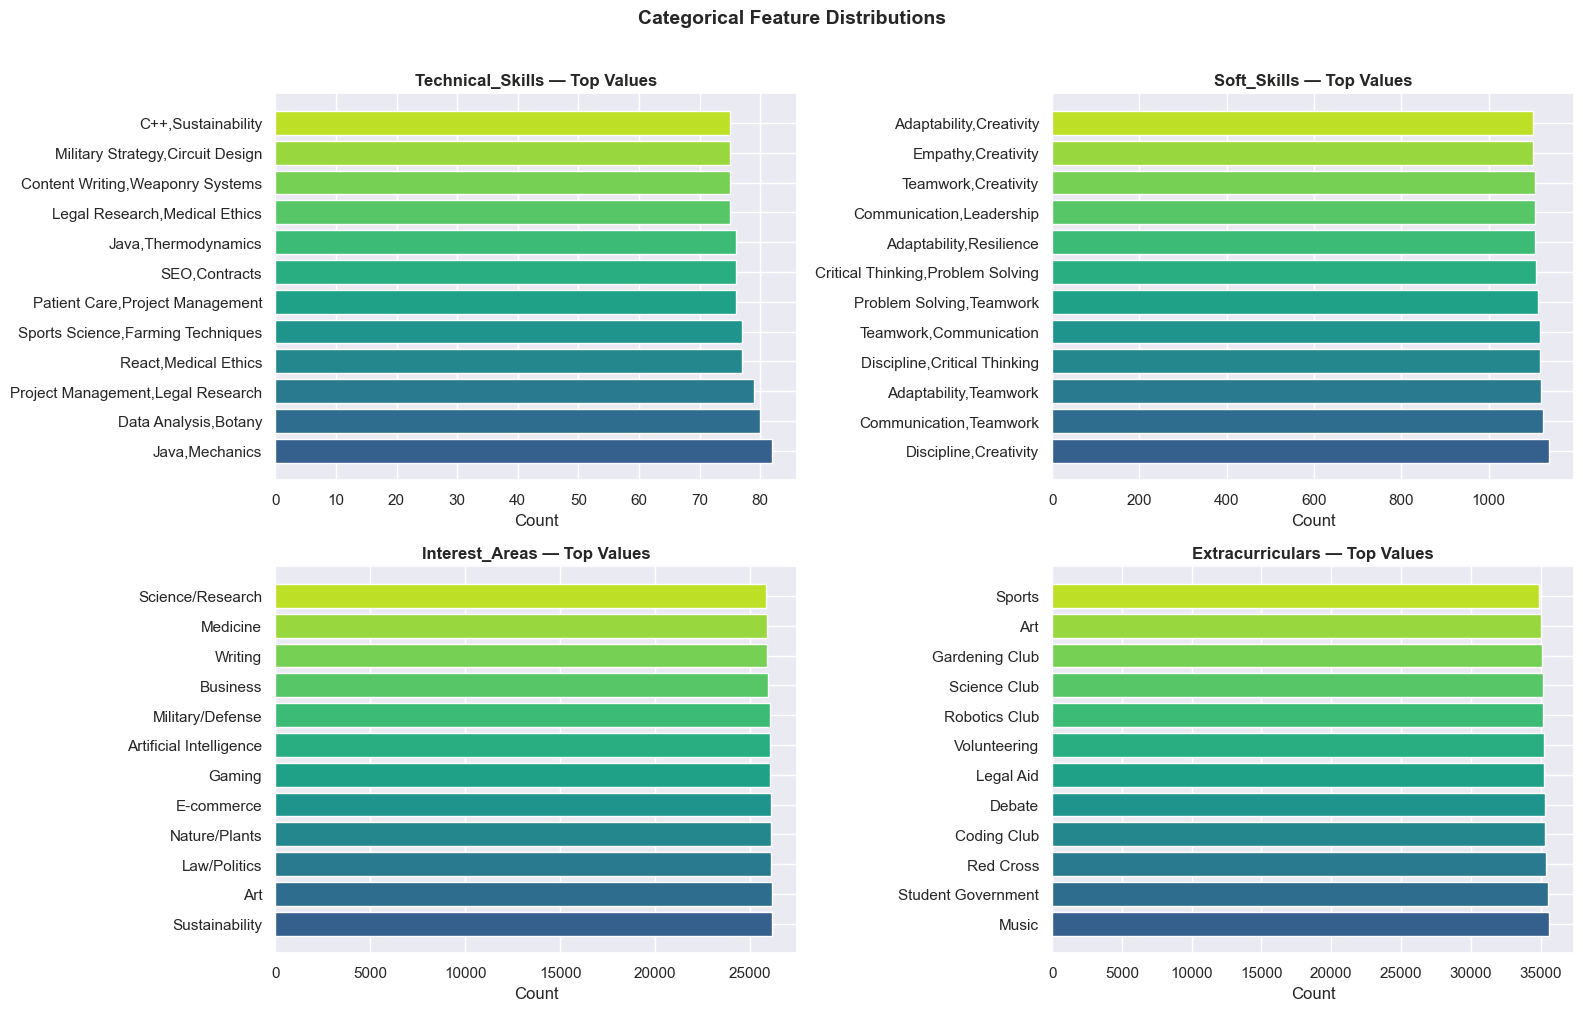

In [19]:
# ── Categorical Feature Distributions ────────────────────────────────────────
cat_cols = [c for c in df.select_dtypes('object').columns if c != 'Career_Path' and c != 'User_ID']

cols_to_plot = cat_cols[:4]  # limit to 4 for display
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    top_vals = df[col].value_counts().head(12)
    axes[i].barh(top_vals.index, top_vals.values, color=plt.cm.viridis(np.linspace(0.3, 0.9, len(top_vals))))
    axes[i].set_title(f'{col} — Top Values', fontweight='bold')
    axes[i].set_xlabel('Count')

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## ⚙️ Section 7 — Feature Engineering

✅ Technical skill features  : 48
✅ Soft skill features       : 13


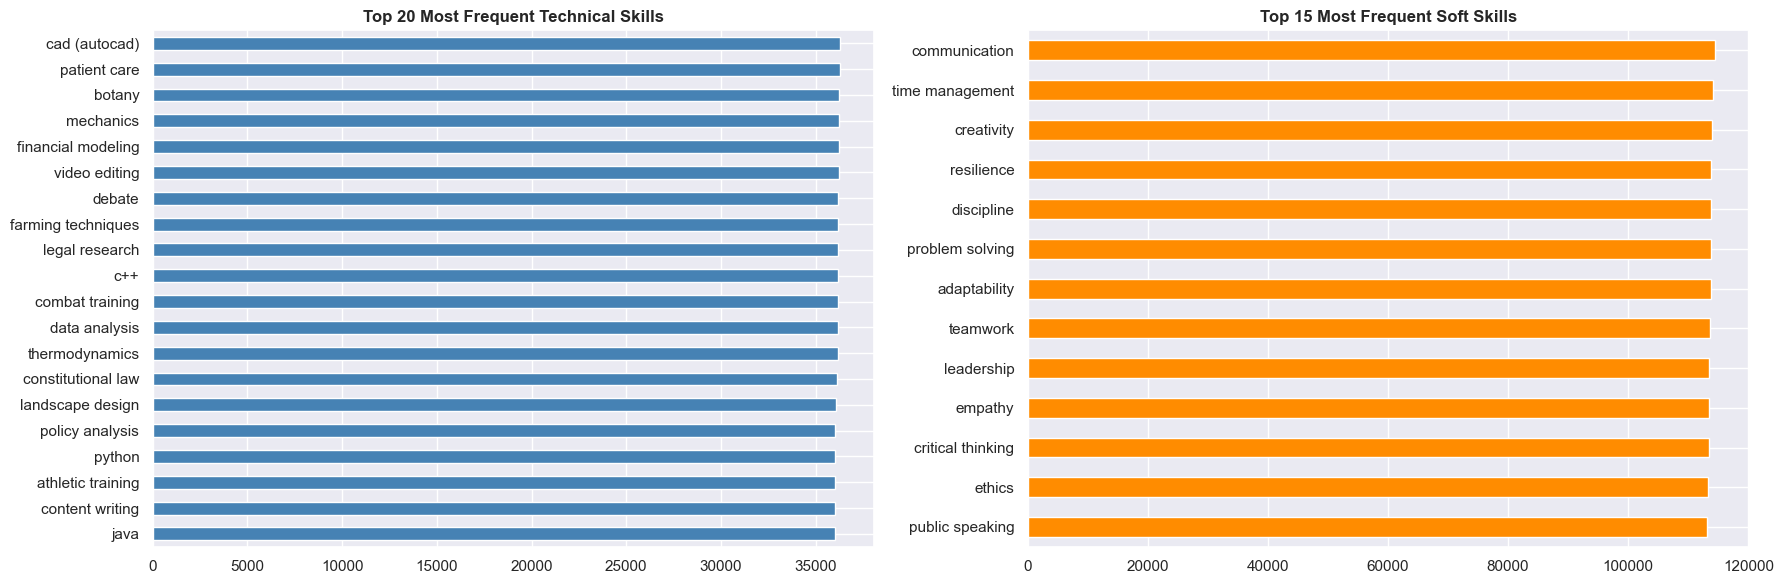

In [20]:
# ── Tokenizer for comma-separated skill strings ────────────────────────────────
def comma_tokenizer(text):
    return [t.strip() for t in str(text).split(',') if t.strip()]

# ── Vectorize skills ──────────────────────────────────────────────────────────
tech_col = 'Technical_Skills'
soft_col = 'Soft_Skills'

tech_vec = CountVectorizer(tokenizer=comma_tokenizer, token_pattern=None, max_features=200)
soft_vec = CountVectorizer(tokenizer=comma_tokenizer, token_pattern=None, max_features=100)

X_tech = tech_vec.fit_transform(df[tech_col])
X_soft = soft_vec.fit_transform(df[soft_col])

print(f'✅ Technical skill features  : {X_tech.shape[1]}')
print(f'✅ Soft skill features       : {X_soft.shape[1]}')

# ── Top N Skills Chart ────────────────────────────────────────────────────────
tech_freq = pd.Series(X_tech.toarray().sum(axis=0), index=tech_vec.get_feature_names_out()).sort_values(ascending=False)
soft_freq = pd.Series(X_soft.toarray().sum(axis=0), index=soft_vec.get_feature_names_out()).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

tech_freq.head(20).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Most Frequent Technical Skills', fontweight='bold')
axes[0].invert_yaxis()

soft_freq.head(15).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 15 Most Frequent Soft Skills', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [21]:
# ── Label Encode remaining categorical columns ────────────────────────────────
le_interest = LabelEncoder()
le_extra    = LabelEncoder()
le_career   = LabelEncoder()

interest_col = 'Interest_Areas'
extra_col    = 'Extracurriculars'

df['interest_enc'] = le_interest.fit_transform(df[interest_col].astype(str))
df['extra_enc']    = le_extra.fit_transform(df[extra_col].astype(str))
y                  = le_career.fit_transform(df['Career_Path'])

print(f'✅ Classes (career paths): {len(le_career.classes_)}')
print(f'   Sample: {list(le_career.classes_[:8])} ...')

# ── Assemble final feature matrix ────────────────────────────────────────────
X = hstack([
    df[['Academic_Percentage', 'interest_enc', 'extra_enc']].values,
    X_tech,
    X_soft
])

print(f'\n📐 Final feature matrix shape: {X.shape}')
print(f'   Training samples         : {X.shape[0]:,}')
print(f'   Total features           : {X.shape[1]}')

✅ Classes (career paths): 33
   Sample: ['Accountant', 'Agriculturist', 'Air Force Pilot', 'Army Officer', 'Biologist', 'Botanist', 'Chemist', 'Civil Engineer'] ...

📐 Final feature matrix shape: (492754, 64)
   Training samples         : 492,754
   Total features           : 64


In [22]:
# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'📊 Train set : {X_train.shape[0]:,} rows ({X_train.shape[0]/X.shape[0]*100:.0f}%)')
print(f'📊 Test set  : {X_test.shape[0]:,} rows ({X_test.shape[0]/X.shape[0]*100:.0f}%)')

📊 Train set : 394,203 rows (80%)
📊 Test set  : 98,551 rows (20%)


## 🤖 Section 8 — Model Training

In [23]:
# ── 8.1 Random Forest ─────────────────────────────────────────────────────────
print('🌳 Training Random Forest Classifier...')
print('   (Uses full dataset — high accuracy model)')

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=25,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f'\n✅ Random Forest Accuracy : {rf_acc:.4f} ({rf_acc:.2%}')
print('\n📋 Classification Report (Random Forest):')
print(classification_report(y_test, y_pred_rf, target_names=le_career.classes_, zero_division=0))

🌳 Training Random Forest Classifier...
   (Uses full dataset — high accuracy model)

✅ Random Forest Accuracy : 0.6843 (68.43%

📋 Classification Report (Random Forest):
                           precision    recall  f1-score   support

               Accountant       0.62      0.67      0.65      3082
            Agriculturist       0.59      0.53      0.56      3143
          Air Force Pilot       0.69      0.79      0.73      2326
             Army Officer       0.78      0.74      0.76      7640
                Biologist       0.54      0.13      0.21       925
                 Botanist       0.65      0.53      0.58      2188
                  Chemist       0.59      0.39      0.47      1012
           Civil Engineer       0.58      0.47      0.52      1436
          Cloud Architect       0.59      0.91      0.72      2131
           Content Writer       0.89      0.87      0.88      7147
    Cybersecurity Analyst       0.63      0.94      0.76      2622
           Data Scientist 

In [24]:
# ── 8.2 SVM (on sampled data) ─────────────────────────────────────────────────
print('⚡ Training Linear SVM Classifier (on 50k sample)...')

n_sample = min(50_000, X_train.shape[0])
idx_samp = np.random.choice(X_train.shape[0], size=n_sample, replace=False)
X_train_samp = X_train[idx_samp]
y_train_samp = y_train[idx_samp]

svm_model = LinearSVC(dual=False, max_iter=2000, random_state=42)
svm_model.fit(X_train_samp, y_train_samp)
y_pred_svm = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred_svm)

print(f'\n✅ SVM Accuracy : {svm_acc:.4f} ({svm_acc:.2%})')

⚡ Training Linear SVM Classifier (on 50k sample)...

✅ SVM Accuracy : 0.6425 (64.25%)


In [25]:
# ── 8.3 KNN (on sampled data) ─────────────────────────────────────────────────
print('🔍 Training KNN Classifier (on 50k sample, dense subset)...')

# KNN requires dense arrays
from scipy.sparse import issparse
X_ts = X_train_samp.toarray() if issparse(X_train_samp) else X_train_samp
X_te = X_test.toarray()       if issparse(X_test)       else X_test

knn_model = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
knn_model.fit(X_ts, y_train_samp)
y_pred_knn = knn_model.predict(X_te)
knn_acc = accuracy_score(y_test, y_pred_knn)

print(f'\n✅ KNN Accuracy : {knn_acc:.4f} ({knn_acc:.2%})')

🔍 Training KNN Classifier (on 50k sample, dense subset)...

✅ KNN Accuracy : 0.2402 (24.02%)


## 📈 Section 9 — Model Comparison & Results

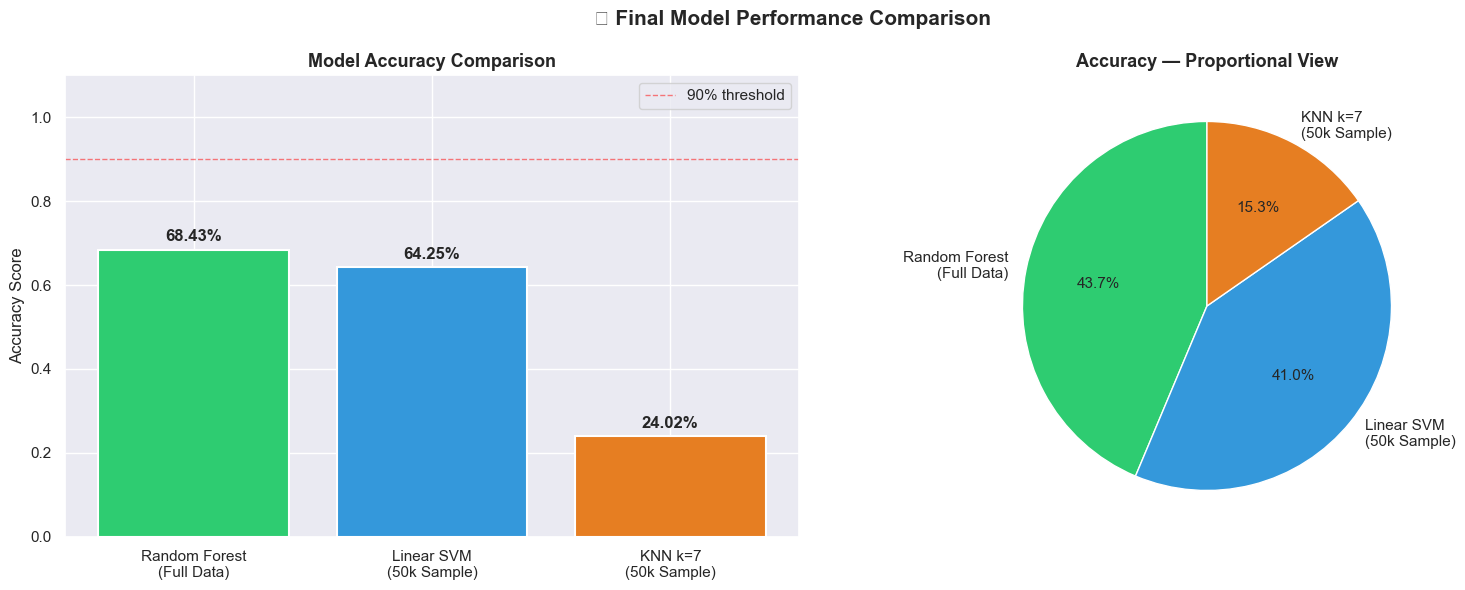

In [26]:
# ── Accuracy Comparison Bar Chart ─────────────────────────────────────────────
results = {
    'Random Forest\n(Full Data)' : rf_acc,
    'Linear SVM\n(50k Sample)'   : svm_acc,
    'KNN k=7\n(50k Sample)'      : knn_acc,
}

palette = ['#2ecc71', '#3498db', '#e67e22']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
bars = axes[0].bar(results.keys(), results.values(), color=palette, edgecolor='white', linewidth=1.5)
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy Score')
axes[0].set_ylim(0, 1.1)
axes[0].axhline(0.9, color='red', linewidth=1, linestyle='--', alpha=0.5, label='90% threshold')
axes[0].legend()
for bar, val in zip(bars, results.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2%}', ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(
    results.values(), labels=results.keys(), autopct='%1.1f%%',
    colors=palette, startangle=90, textprops={'fontsize': 11}
)
axes[1].set_title('Accuracy — Proportional View', fontsize=13, fontweight='bold')

plt.suptitle('🏆 Final Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

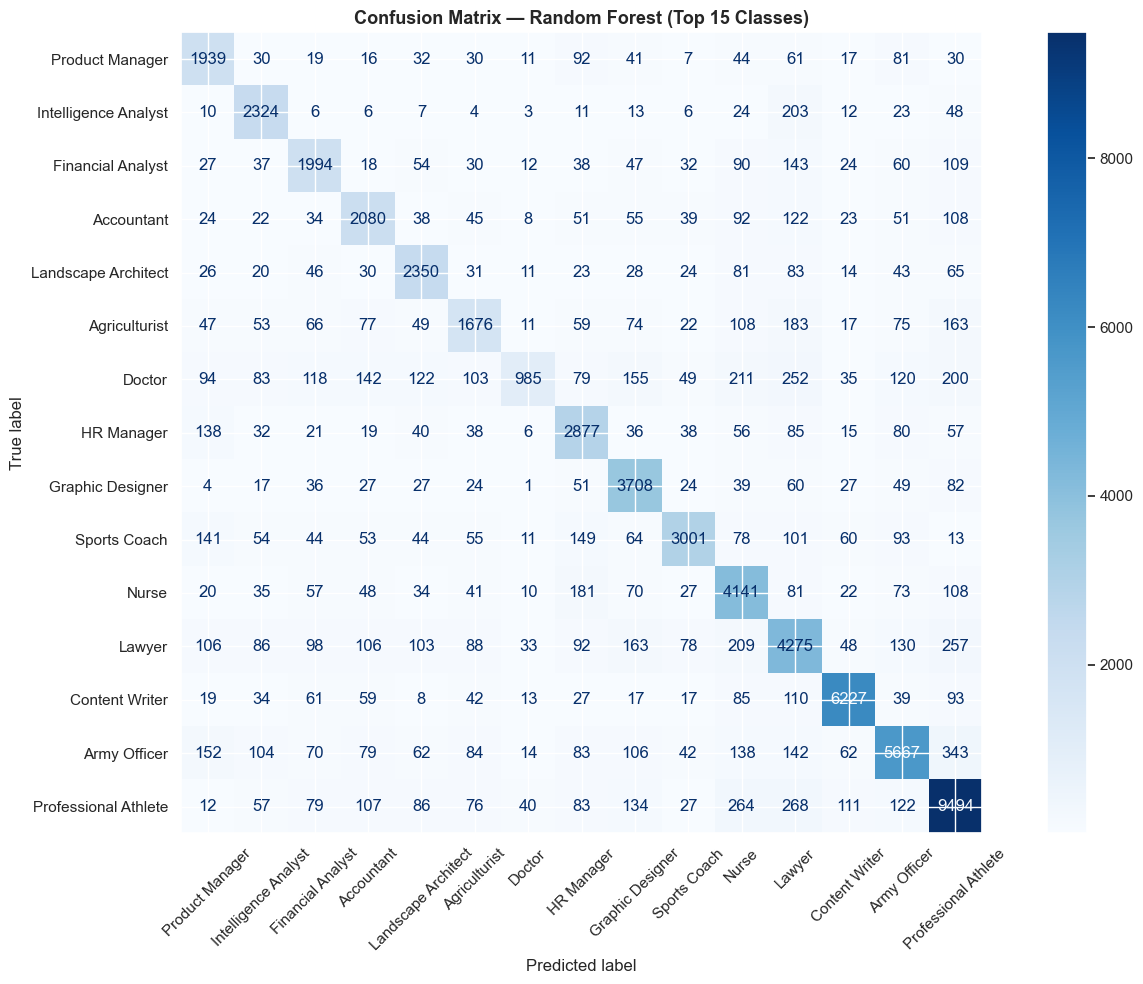

In [27]:
# ── Confusion Matrix — Random Forest (best model) ─────────────────────────────
# Show only top 15 classes for readability
top15_idx   = np.argsort(np.bincount(y_test))[-15:]
top15_mask  = np.isin(y_test, top15_idx)
y_test_top  = y_test[top15_mask]
y_pred_top  = y_pred_rf[top15_mask]

cm = confusion_matrix(y_test_top, y_pred_top, labels=top15_idx)
top15_labels = le_career.classes_[top15_idx]

fig, ax = plt.subplots(figsize=(14, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top15_labels)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title('Confusion Matrix — Random Forest (Top 15 Classes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

🔑 Top 20 Most Important Features:
content writing          0.111185
sports science           0.055020
Interest_Areas           0.050879
discipline               0.042519
leadership               0.038927
Extracurriculars         0.038031
military strategy        0.030328
empathy                  0.029271
resilience               0.029113
patient care             0.028819
communication            0.027559
coaching                 0.026831
graphic design           0.025224
Academic_Percentage      0.024817
cybersecurity            0.024785
navigation               0.020807
critical thinking        0.019294
intelligence analysis    0.018864
legal research           0.018684
creativity               0.017676


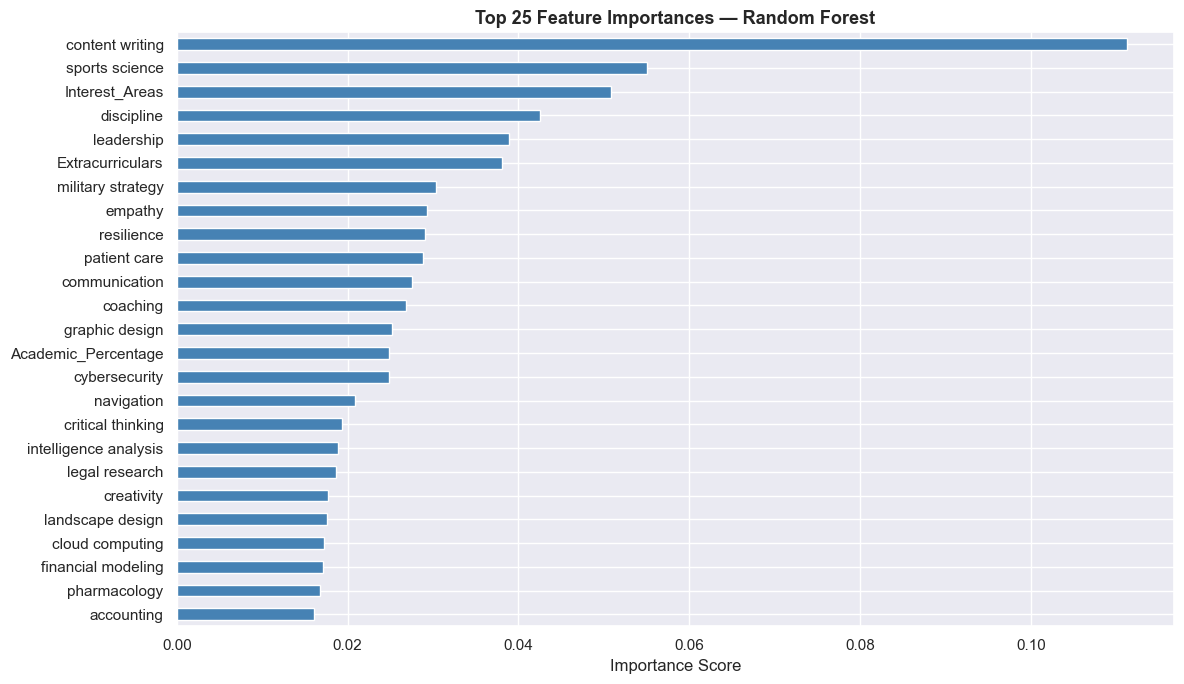

In [28]:
# ── Feature Importances — Random Forest ──────────────────────────────────────
feature_names = (
    ['Academic_Percentage', 'Interest_Areas', 'Extracurriculars']
    + list(tech_vec.get_feature_names_out())
    + list(soft_vec.get_feature_names_out())
)

importances = rf_model.feature_importances_
fi_series   = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print('🔑 Top 20 Most Important Features:')
print(fi_series.head(20).to_string())

plt.figure(figsize=(12, 7))
fi_series.head(25).plot(kind='barh', color='steelblue')
plt.title('Top 25 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [29]:
# ── Final Summary Table ───────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model'           : ['Random Forest', 'Linear SVM', 'KNN (k=7)'],
    'Training Data'   : ['Full Dataset', '50k Sample', '50k Sample'],
    'Accuracy'        : [rf_acc, svm_acc, knn_acc],
    'Accuracy (%)'    : [f'{rf_acc:.2%}', f'{svm_acc:.2%}', f'{knn_acc:.2%}'],
    'Recommended'     : ['✅ Yes (Production)', '⚠️ Comparison Only', '⚠️ Comparison Only'],
})

print('\n' + '=' * 65)
print('FINAL MODEL SUMMARY')
print('=' * 65)
print(summary.to_string(index=False))
print('=' * 65)
best = summary.loc[summary['Accuracy'].idxmax(), 'Model']
print(f'\n🏆 Best Model: {best}')


FINAL MODEL SUMMARY
        Model Training Data  Accuracy Accuracy (%)        Recommended
Random Forest  Full Dataset  0.684295       68.43% ✅ Yes (Production)
   Linear SVM    50k Sample  0.642490       64.25% ⚠️ Comparison Only
    KNN (k=7)    50k Sample  0.240170       24.02% ⚠️ Comparison Only

🏆 Best Model: Random Forest
